In [1]:
import pandas as pd
import protfasta
import requests
import re
import warnings
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from Bio import AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

import rich
from rich_msa import RichAlignment
import logomaker

warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


# Visualizing percent identity

In [30]:
# Read and concatenate all CSV files in the specified directory
path = "/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/output/ensembl_orthologs/human_TF_percent_identities"
all_files = glob.glob(os.path.join(path, "*.csv"))

# Combine all files into a single DataFrame and add 'ENSG' column
df_combined = pd.concat(
    (pd.read_csv(file).assign(ENSG=os.path.basename(file).split(".")[0]) for file in all_files),
    ignore_index=True
)
df_combined

,human_position,alignment_column,human_aa,percent_identity,gap_fraction,aligns_to_AD,ENSG
0,1,383,M,90.769231,0.076923,False,ENSG00000156469
1,2,384,A,80.000000,0.076923,False,ENSG00000156469
2,3,385,L,57.948718,0.082051,False,ENSG00000156469
3,4,386,S,43.076923,0.082051,False,ENSG00000156469
4,5,387,A,53.846154,0.087179,False,ENSG00000156469
...,...,...,...,...,...,...,...
265453,251,1369,I,53.768844,0.025126,True,ENSG00000111049
265454,252,1370,Y,94.472362,0.020101,True,ENSG00000111049
265455,253,1371,H,90.954774,0.020101,True,ENSG00000111049
265456,254,1372,V,90.954774,0.020101,True,ENSG00000111049


In [7]:
df_combined_AD = df_combined[df_combined["aligns_to_AD"]]
df_combined_AD

,human_position,alignment_column,human_aa,percent_identity,gap_fraction,aligns_to_AD
81,82,587,S,48.205128,0.051282,True
82,83,603,A,33.846154,0.123077,True
83,84,604,Q,46.666667,0.097436,True
84,85,605,S,55.897436,0.092308,True
85,86,606,S,13.846154,0.097436,True
...,...,...,...,...,...,...
265453,251,1369,I,53.768844,0.025126,True
265454,252,1370,Y,94.472362,0.020101,True
265455,253,1371,H,90.954774,0.020101,True
265456,254,1372,V,90.954774,0.020101,True


In [8]:
df_combined_non_AD = df_combined[~df_combined["aligns_to_AD"]]
df_combined_non_AD

,human_position,alignment_column,human_aa,percent_identity,gap_fraction,aligns_to_AD
0,1,383,M,90.769231,0.076923,False
1,2,384,A,80.000000,0.076923,False
2,3,385,L,57.948718,0.082051,False
3,4,386,S,43.076923,0.082051,False
4,5,387,A,53.846154,0.087179,False
...,...,...,...,...,...,...
265332,130,896,Y,99.497487,0.000000,False
265333,131,897,I,100.000000,0.000000,False
265334,132,898,E,97.487437,0.000000,False
265335,133,899,S,95.979899,0.000000,False


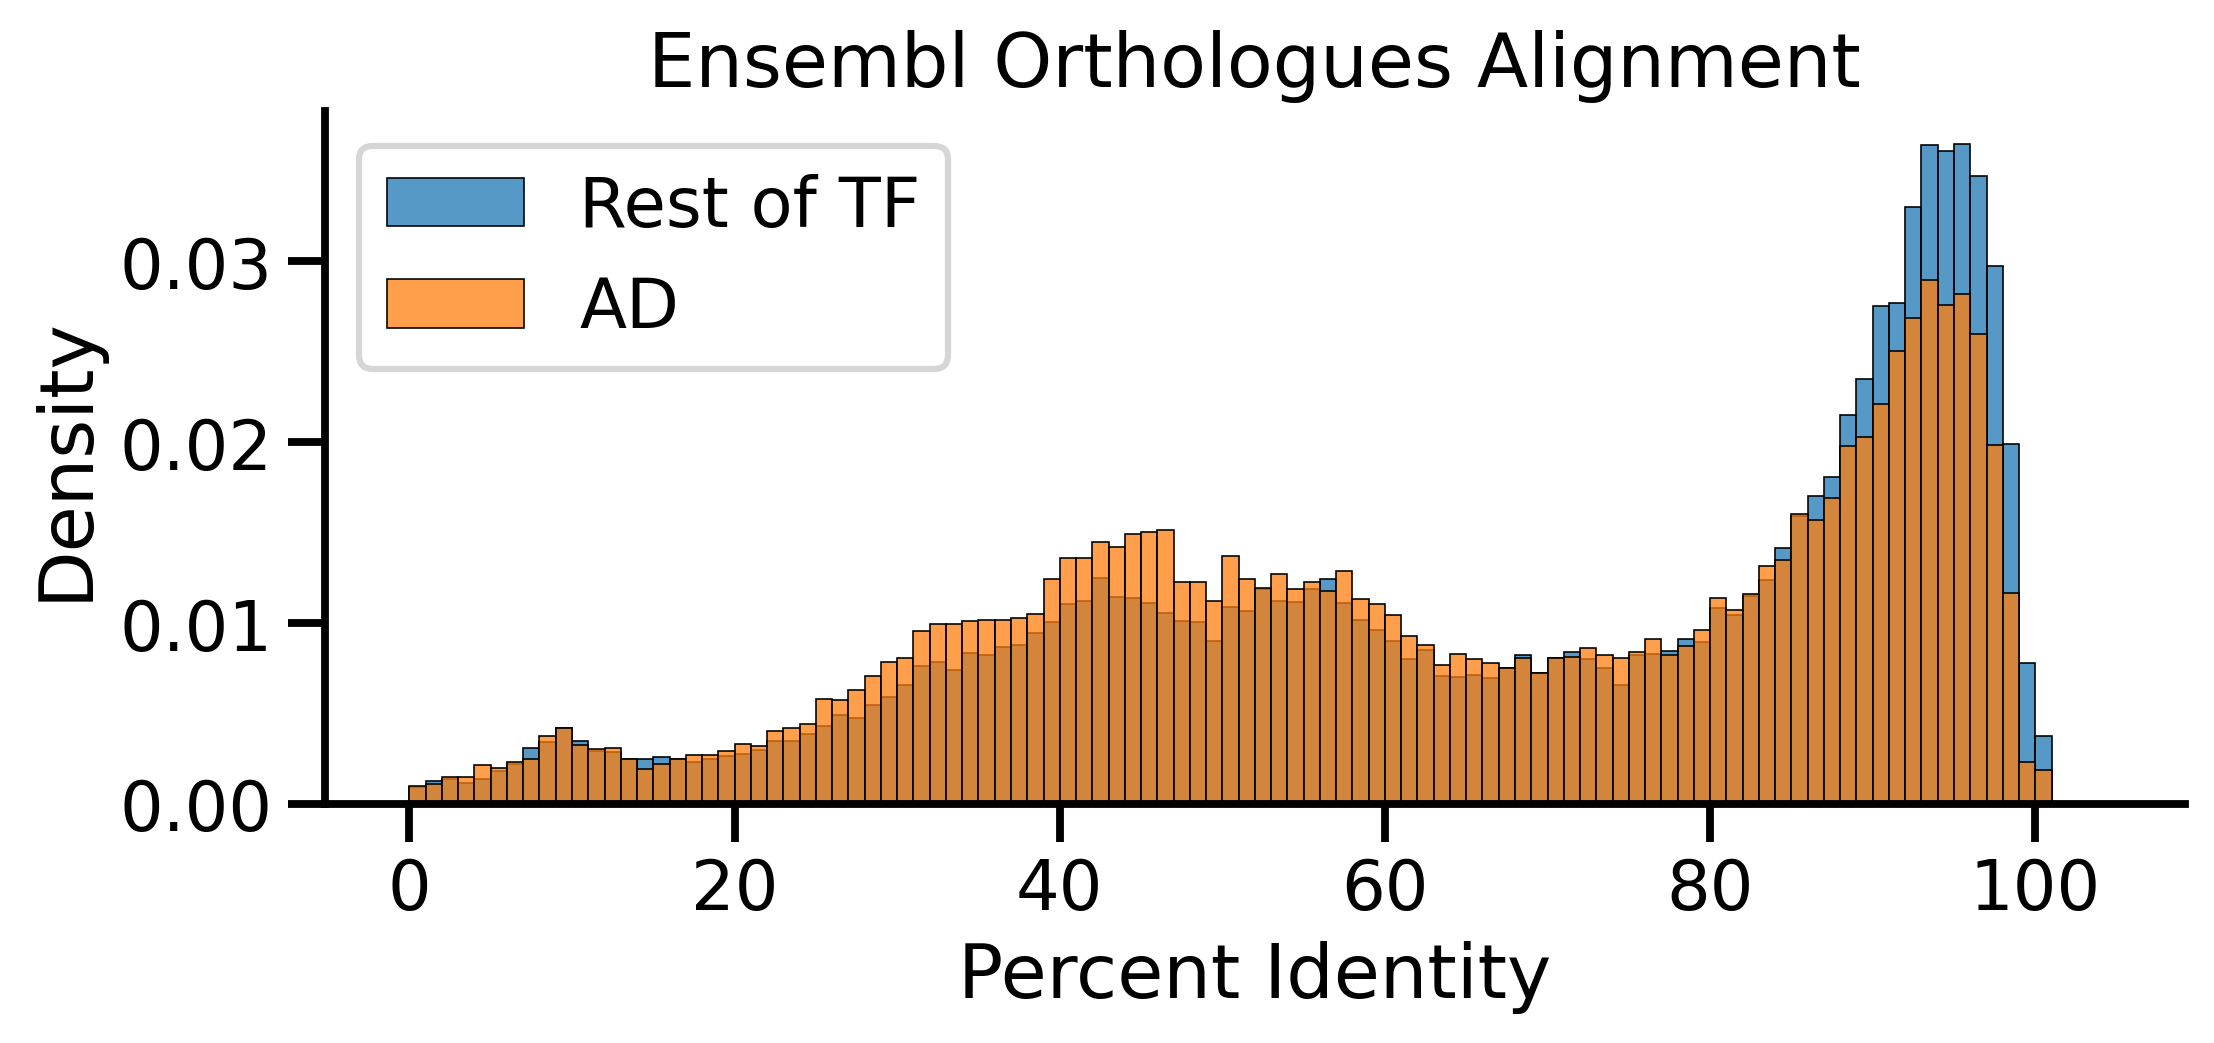

In [132]:
sns.set_context('talk')
plt.figure(dpi = 300, figsize = (8,3))
sns.histplot(data = df_combined_non_AD, x = "percent_identity", stat = 'density', label = "Rest of TF", bins = np.arange(0,105,1))
sns.histplot(data = df_combined_AD, x = "percent_identity", stat = 'density', label = "AD", bins = np.arange(0,105,1))
plt.xlabel("Percent Identity")
plt.legend()
plt.title("Ensembl Orthologues Alignment")
sns.despine()

# Percent identity with only short ADs

In [19]:
# Path to the directory containing FASTA files
fasta_path = "/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/output/ensembl_orthologs/AD_fastas"

# List to store the data
ad_lengths = []

# Iterate through each FASTA file in the directory
for fasta_file in glob.glob(os.path.join(fasta_path, "*.fasta")):
    ensg_id = os.path.basename(fasta_file).split(".")[0]  # Extract ENSG ID from the filename
    for record in SeqIO.parse(fasta_file, "fasta"):
        ad_lengths.append({"ENSG": ensg_id, "AD_Length": len(record.seq)})

# Create a DataFrame to store the results
df_ad_lengths = pd.DataFrame(ad_lengths)
df_ad_lengths

,ENSG,AD_Length
0,ENSG00000108511,80
1,ENSG00000095794,254
2,ENSG00000113430,80
3,ENSG00000163435,90
4,ENSG00000163435,100
...,...,...
604,ENSG00000196482,123
605,ENSG00000196482,194
606,ENSG00000213921,90
607,ENSG00000137504,110


In [20]:
# Path to the directory containing ortholog FASTA files
ortholog_fasta_path = "/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/output/ensembl_orthologs/ortholog_fastas"

# List to store the full lengths
full_lengths = []

# Iterate through each FASTA file in the directory
for fasta_file in glob.glob(os.path.join(ortholog_fasta_path, "*.fasta")):
    ensg_id = os.path.basename(fasta_file).split(".")[0].split("_")[0]  # Extract ENSG ID from the filename
    for record in SeqIO.parse(fasta_file, "fasta"):
        if "homo_sapiens" in record.id:  # Check if 'homo_sapiens' is in the record ID
            full_lengths.append({"ENSG": ensg_id, "Full_Length": len(record.seq)})

# Create a DataFrame for full lengths
df_full_lengths = pd.DataFrame(full_lengths)

# Merge the full lengths with the existing df_ad_lengths
df_ad_lengths = df_ad_lengths.merge(df_full_lengths, on="ENSG", how="left")
df_ad_lengths

,ENSG,AD_Length,Full_Length
0,ENSG00000108511,80,224
1,ENSG00000095794,254,299
2,ENSG00000113430,80,519
3,ENSG00000163435,90,371
4,ENSG00000163435,100,371
...,...,...,...
604,ENSG00000196482,123,458
605,ENSG00000196482,194,458
606,ENSG00000213921,90,198
607,ENSG00000137504,110,354


In [24]:
# Group by ENSG and calculate the summed AD length
df_ad_lengths['Summed_AD_Length'] = df_ad_lengths.groupby('ENSG')['AD_Length'].transform('sum')

# Calculate the ratio of summed AD length to full length
df_ad_lengths['AD_Length_Ratio'] = df_ad_lengths['Summed_AD_Length'] / df_ad_lengths['Full_Length']

# Drop duplicate rows to keep only one row per ENSG
df_ad_lengths_unique = df_ad_lengths.drop_duplicates(subset='ENSG')
df_ad_lengths_unique

,ENSG,AD_Length,Full_Length,Summed_AD_Length,AD_Length_Ratio
0,ENSG00000108511,80,224,80,0.357143
1,ENSG00000095794,254,299,254,0.849498
2,ENSG00000113430,80,519,80,0.154143
3,ENSG00000163435,90,371,190,0.512129
5,ENSG00000269404,21,262,52,0.198473
...,...,...,...,...,...
603,ENSG00000072736,16,1075,16,0.014884
604,ENSG00000196482,123,458,317,0.692140
606,ENSG00000213921,90,198,90,0.454545
607,ENSG00000137504,110,354,110,0.310734


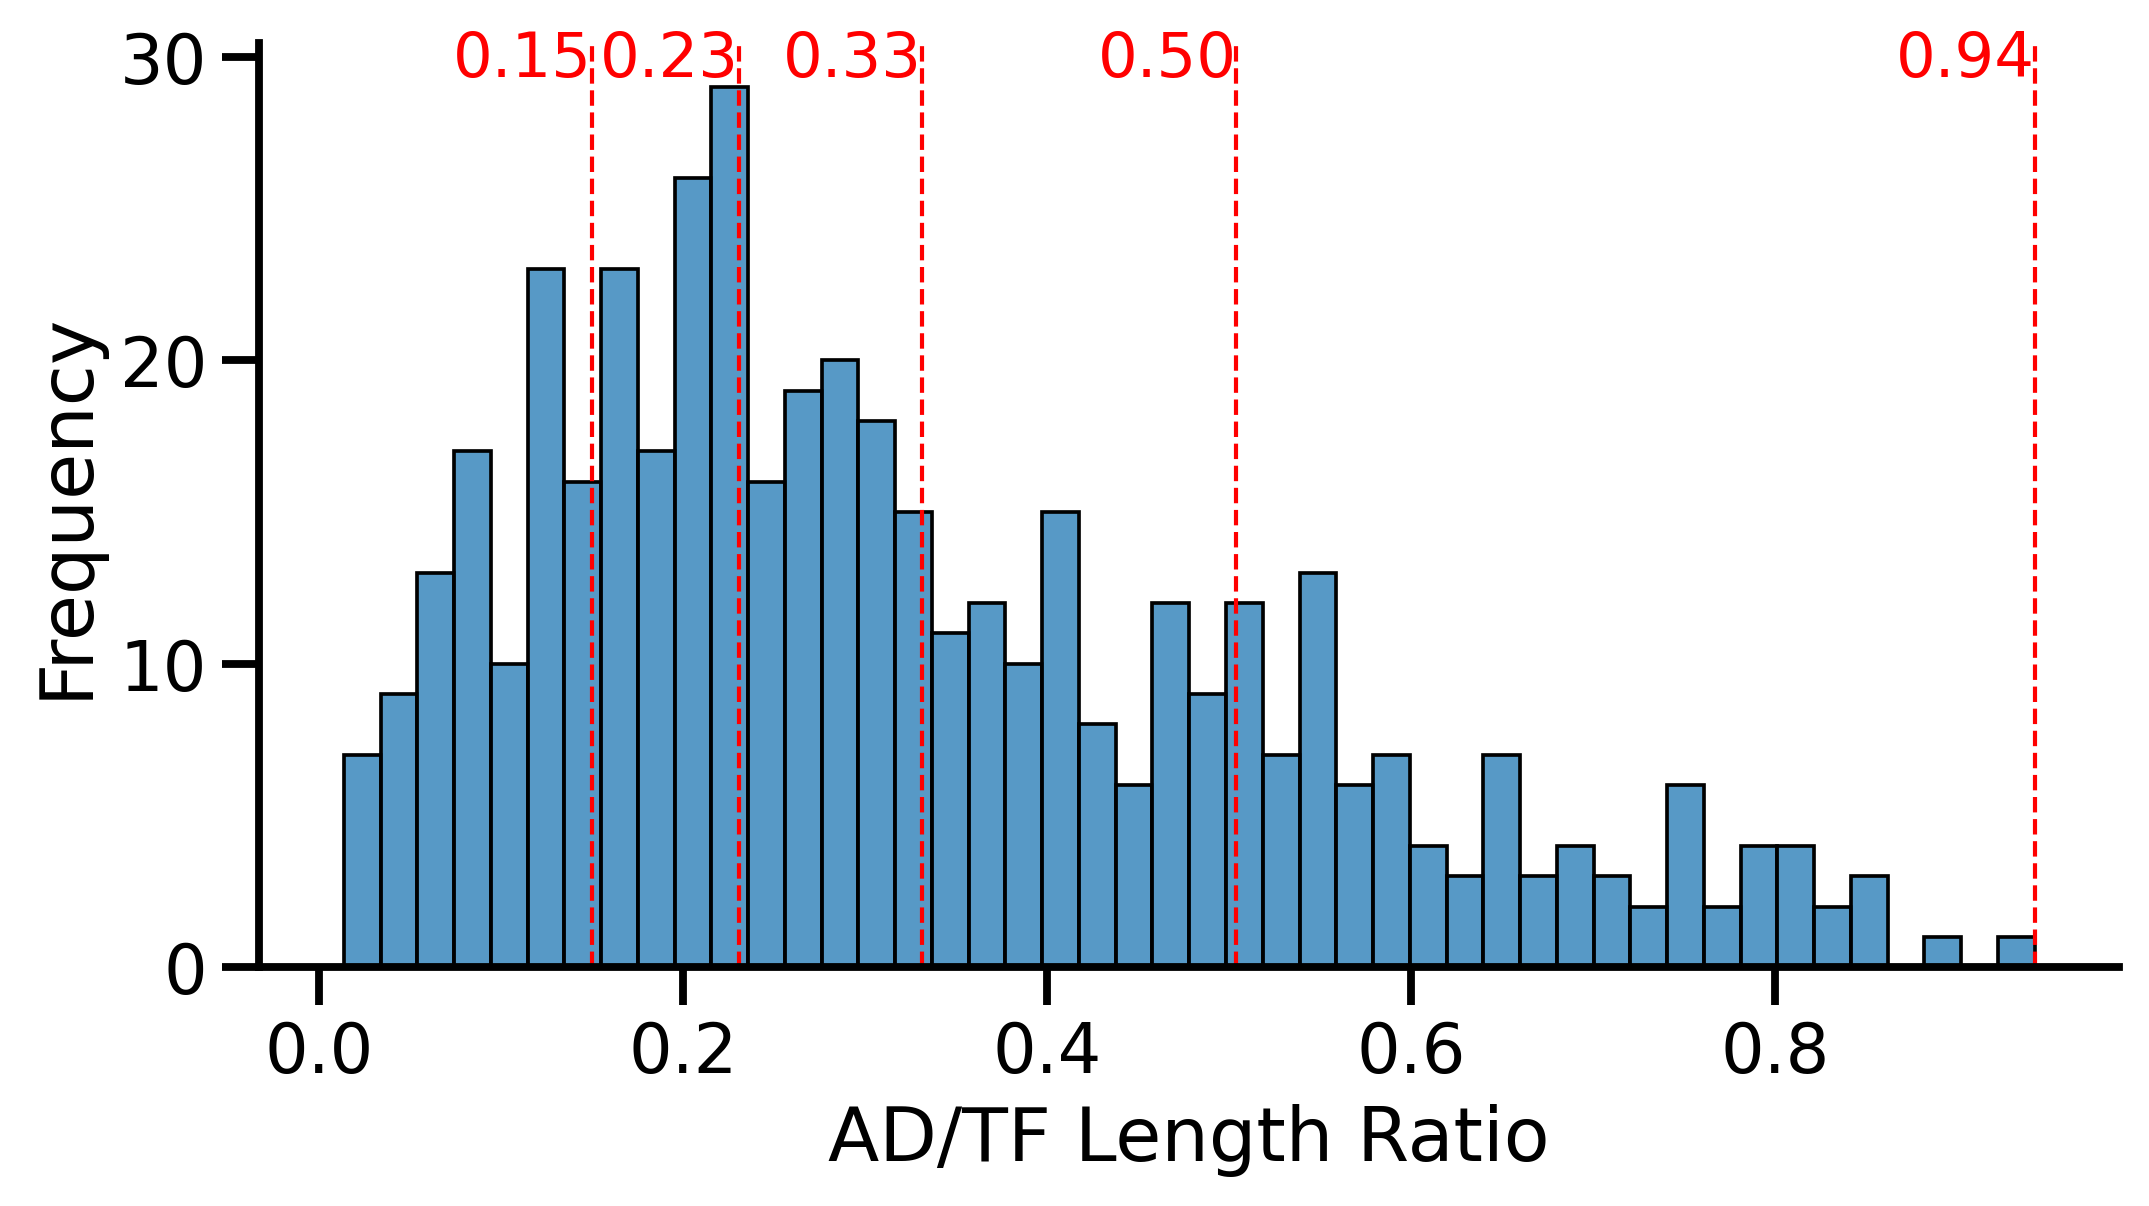

In [129]:
plt.figure(figsize = (8,4), dpi = 300)

sns.histplot(df_ad_lengths_unique["AD_Length_Ratio"], binwidth=0.02)

# Draw vertical lines at quintiles and add numerical labels
for threshold in percentile_thresholds:
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1)
    plt.text(threshold, plt.ylim()[1] * 0.95, f"{threshold:.2f}", color='red', ha='right', va='bottom', fontsize='small')

plt.xlabel("AD/TF Length Ratio")
plt.ylabel("Frequency")
sns.despine()

plt.show()


0 0.09369180413045619
0.09369180413045619 0.23066265521999083
0.23066265521999083 0.3310566029028313
0.3310566029028313 0.5039559940286886
0.5039559940286886 0.9425981873111783


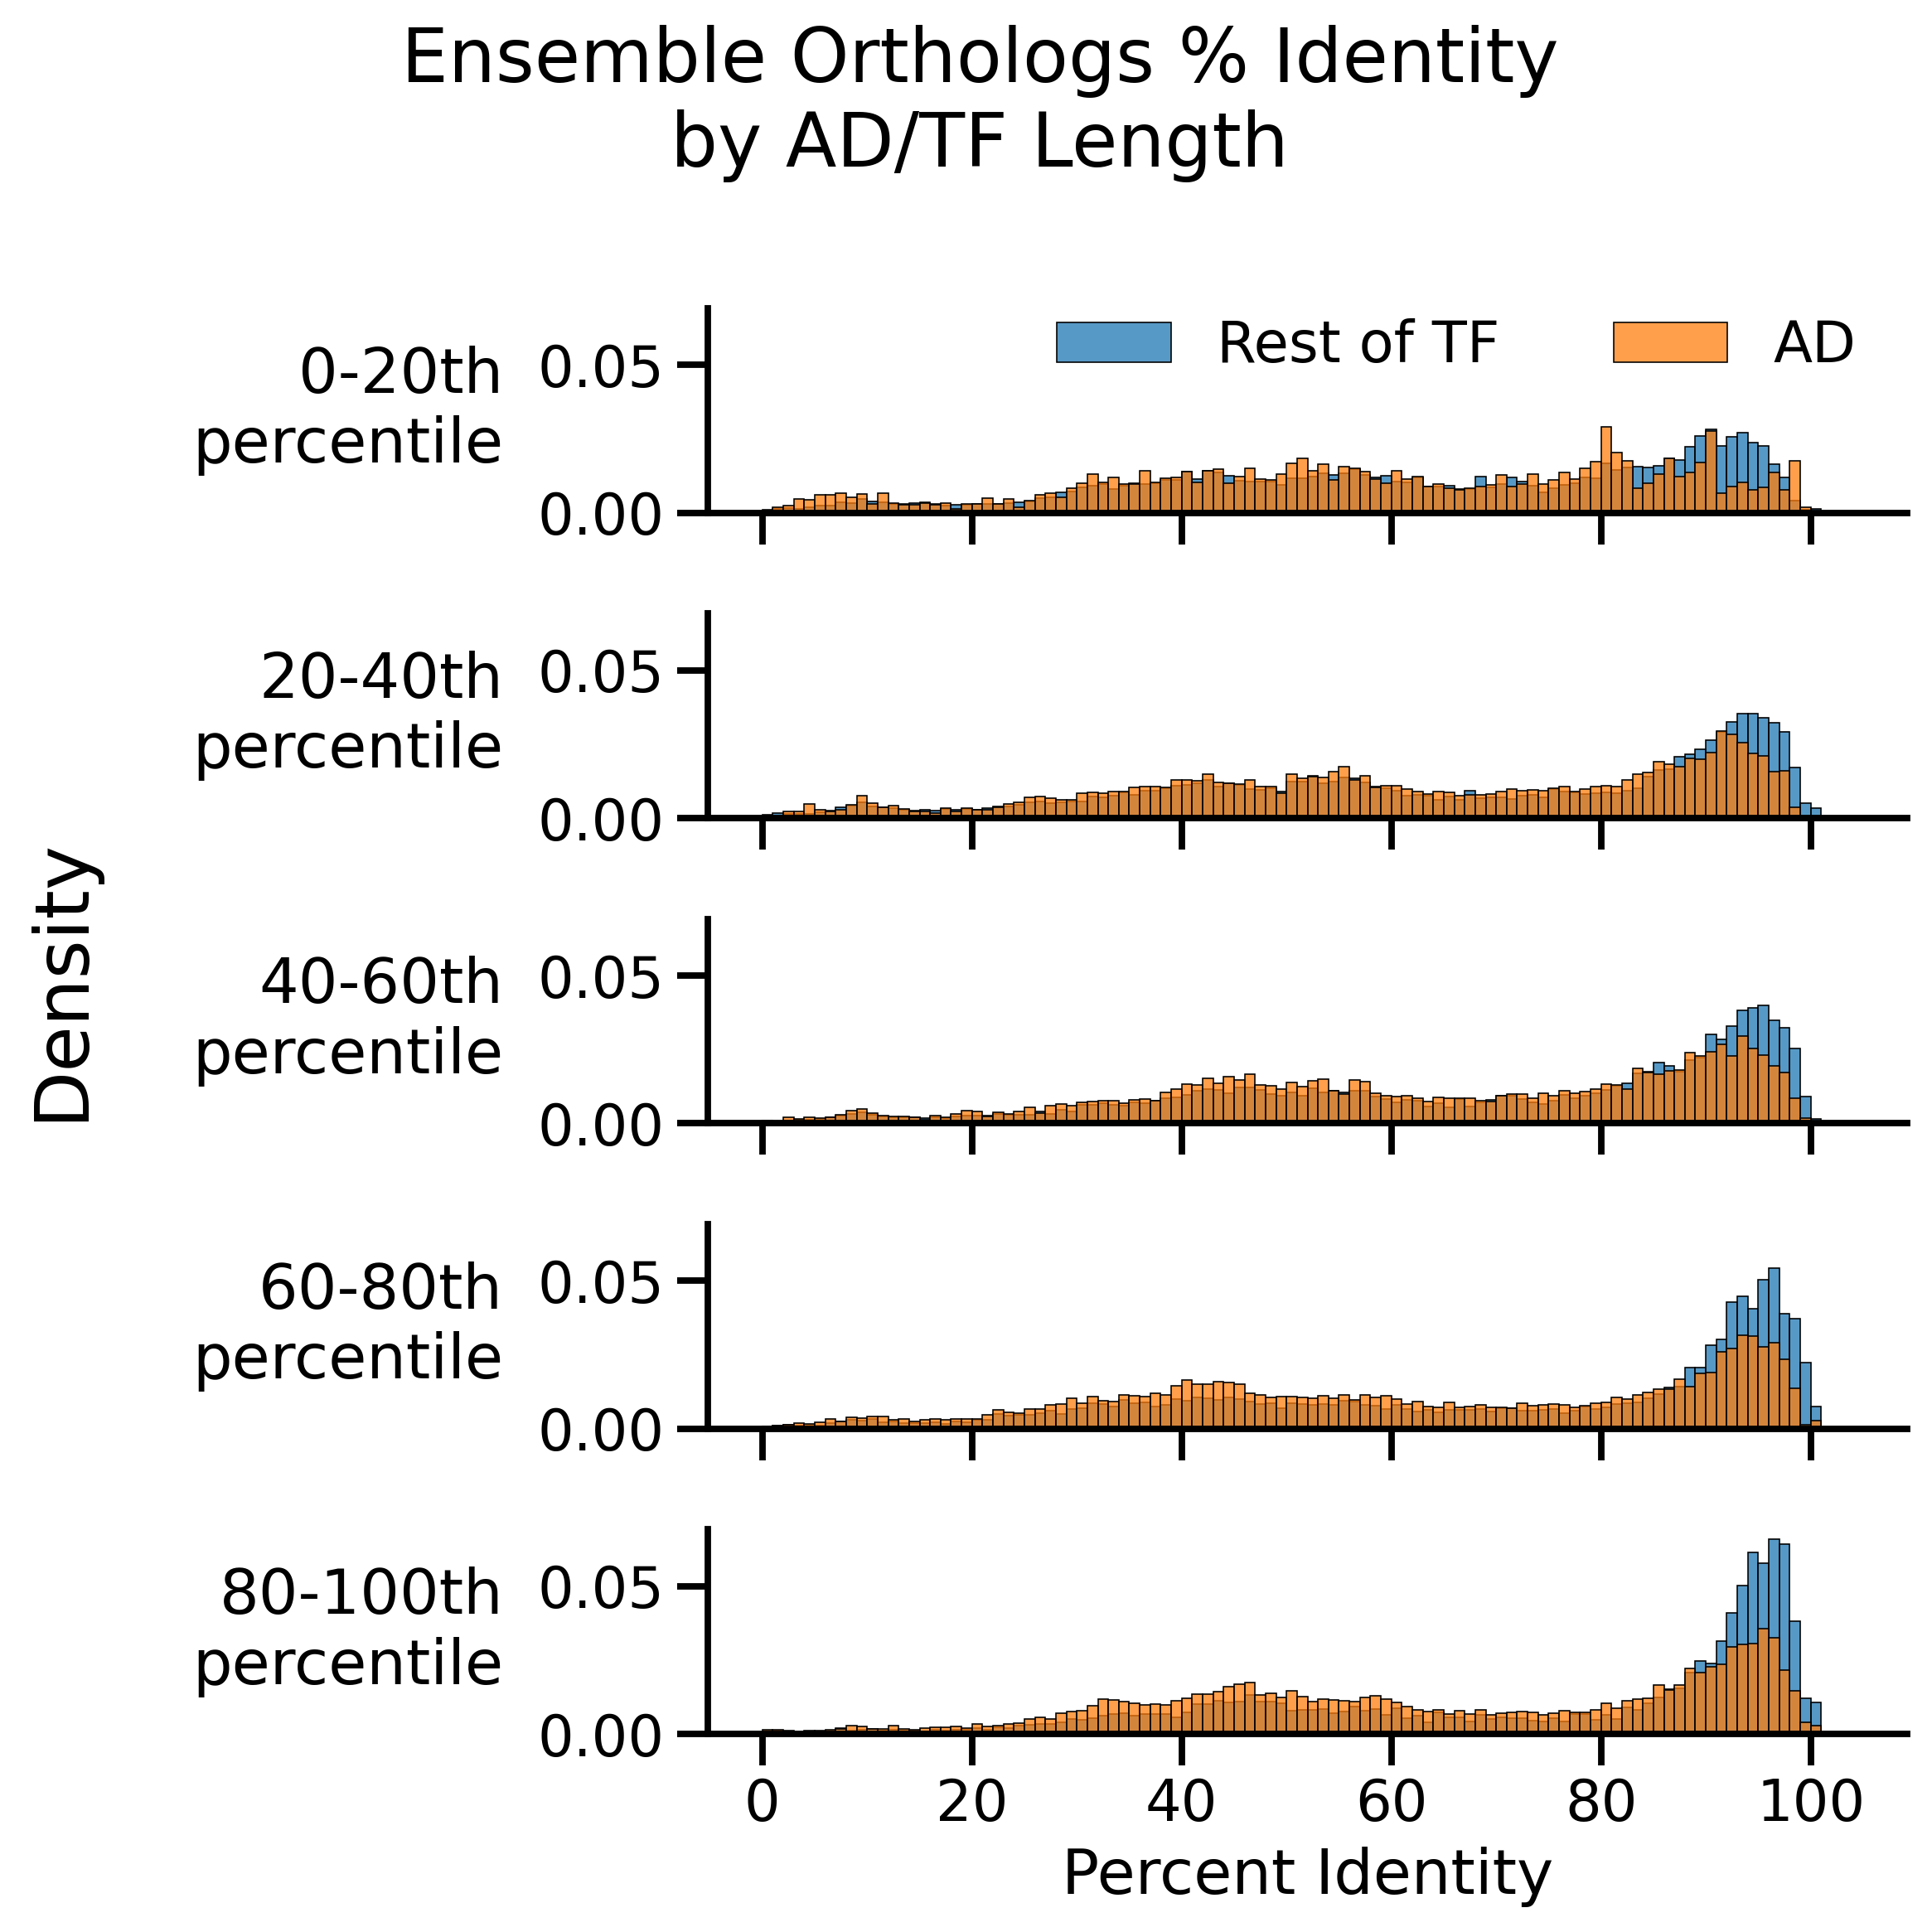

In [131]:
# Define the quantile ranges
quantiles = [0.1, 0.4, 0.6, 0.8, 1.0]
quantile_labels = ["0-20th\npercentile", "20-40th\npercentile", "40-60th\npercentile", "60-80th\npercentile", "80-100th\npercentile"]

# Create subplots for 5 quantile ranges
sns.set_context('talk')
fig, axes = plt.subplots(5, 1, figsize=(8, 8), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

# Iterate through quantile ranges
for i in range(len(quantiles)):
    if i == 0:
        lower_bound = 0  # Set lower bound to 0 for the first quantile
    else:
        lower_bound = df_ad_lengths_unique['AD_Length_Ratio'].quantile(quantiles[i - 1])
    upper_bound = df_ad_lengths_unique['AD_Length_Ratio'].quantile(quantiles[i])

    print(lower_bound, upper_bound)

    # Filter the dataframe for the current quantile range
    df_current_quantile = df_ad_lengths_unique[
        (df_ad_lengths_unique['AD_Length_Ratio'] > lower_bound) &
        (df_ad_lengths_unique['AD_Length_Ratio'] <= upper_bound)
    ]

    # Filter df_combined based on the current quantile range
    df_combined_current = df_combined[df_combined["ENSG"].isin(df_current_quantile["ENSG"])]
    df_combined_AD_current = df_combined_current[df_combined_current["aligns_to_AD"]]
    df_combined_non_AD_current = df_combined_current[~df_combined_current["aligns_to_AD"]]

    # Plot the histogram for the current quantile range
    ax = axes[i]
    sns.histplot(data=df_combined_non_AD_current, x="percent_identity", stat='density', label="Rest of TF",
                 bins=np.arange(0, 105, 1), ax=ax)
    sns.histplot(data=df_combined_AD_current, x="percent_identity", stat='density', label="AD",
                 bins=np.arange(0, 105, 1), ax=ax)
    ax.set_ylabel(quantile_labels[i], rotation=0, labelpad=10, ha='right', va='center')

    if i == 0:
        ax.legend(frameon=False, loc = 'upper right', ncols = 2, bbox_to_anchor = (1,1.2))

    sns.despine(ax=ax)

# Add a shared x-axis label and title
plt.xlabel("Percent Identity")
plt.suptitle("Ensemble Orthologs % Identity\nby AD/TF Length")
fig.supylabel("Density")
plt.tight_layout(pad=0)
plt.tight_layout()
plt.show()


In [91]:
# Calculate the thresholds for each percentile
percentile_thresholds = [df_ad_lengths_unique['AD_Length_Ratio'].quantile(q) for q in quantiles]

# Print the thresholds
for q, threshold in zip(quantiles, percentile_thresholds):
    print(f"{int(q * 100)}th percentile: {threshold:.6f}")


20th percentile: 0.149652
40th percentile: 0.230663
60th percentile: 0.331057
80th percentile: 0.503956
100th percentile: 0.942598


In [90]:
df_ad_lengths_unique[df_ad_lengths_unique["ENSG"].isin(df_combined_current["ENSG"])]

,ENSG,AD_Length,Full_Length,Summed_AD_Length,AD_Length_Ratio
1,ENSG00000095794,254,299,254,0.849498
3,ENSG00000163435,90,371,190,0.512129
11,ENSG00000128272,191,351,191,0.544160
16,ENSG00000067082,201,283,201,0.710247
18,ENSG00000081189,387,473,387,0.818182
...,...,...,...,...,...
558,ENSG00000082175,247,933,503,0.539121
572,ENSG00000122180,71,224,140,0.625000
579,ENSG00000139515,148,283,148,0.522968
585,ENSG00000138795,67,399,206,0.516291
